<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/Total_Population_by_State.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

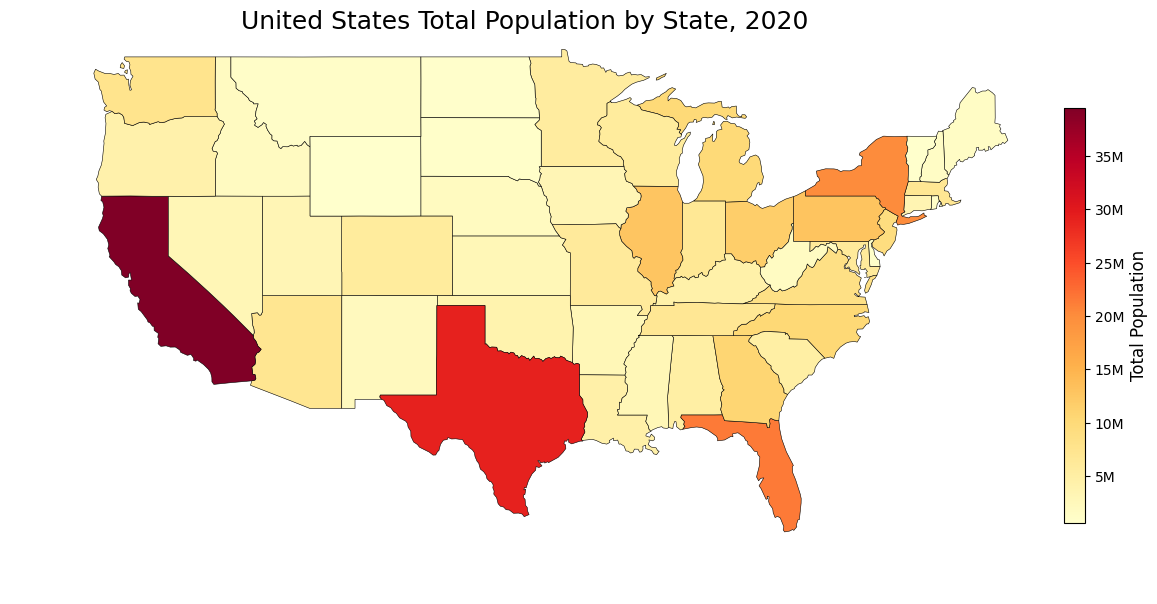

In [2]:
# Run once
# !pip install geopandas pandas numpy matplotlib openpyxl

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter

# Read Excel file
file = "/content/DECENNIALCD1182020.P1-2026-06-17T154341.xlsx"

census_data = pd.read_excel(
    file,
    sheet_name="Data",
    header=None
)

# Row 0 has the state names
# Row 1 has the total population values
states = census_data.iloc[0].copy()
population = census_data.iloc[1].copy()

# Turn into DataFrame
pop_df = pd.DataFrame({
    "state": states,
    "population": population
})

# Remove label row
pop_df = pop_df[pop_df["state"] != "Label"].copy()

# Remove Puerto Rico if only mapping states
pop_df = pop_df[pop_df["state"] != "Puerto Rico"].copy()

# Make population numeric
pop_df["population"] = (
    pop_df["population"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

pop_df["population"] = pd.to_numeric(pop_df["population"], errors="coerce")

# Read state boundaries
url = "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/us-states.json"
state_geo = gpd.read_file(url)

# Merge state boundaries with population data
merged = state_geo.merge(
    pop_df,
    left_on="name",
    right_on="state",
    how="left"
)

# Keep lower 48 states
lower48 = merged.cx[-130:-65, 22:50].copy()

# Make map
fig, ax = plt.subplots(figsize=(16, 9))

lower48.plot(
    column="population",
    cmap="YlOrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.4,
    ax=ax,
    legend_kwds={
        "label": "Total Population",
        "orientation": "vertical",
        "shrink": 0.6,
        "pad": 0.02
    }
)

# Make colorbar numbers easier to read
cbar = ax.get_figure().axes[-1]

cbar.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1_000_000:.0f}M")
)

cbar.set_ylabel("Total Population", fontsize=12)

ax.set_title("United States Total Population by State, 2020", fontsize=18)
ax.set_xlim(-130, -65)
ax.set_ylim(22, 50)
ax.axis("off")

plt.show()